Codigo Elevator Saga - Codigo

In [ ]:
{
  init: function(elevators, floors) {
// Cola de pisos solicitados externamente
let floorRequests = {
up: new Set(),
down: new Set()
};

// Añade piso a la cola si no está
function requestFloor(floorNum, direction) {
if (direction === "up") floorRequests.up.add(floorNum);
else floorRequests.down.add(floorNum);
assignElevators();
}

// Asigna elevadores a solicitudes de piso
function assignElevators() {
elevators.forEach(elevator => {
if (elevator.destinationQueue.length === 0) {
let target = null;
let direction = null;

// Decide qué llamada atender
if (floorRequests.up.size > 0) {
target = getClosestFloor(elevator, floorRequests.up);
direction = "up";
} else if (floorRequests.down.size > 0) {
target = getClosestFloor(elevator, floorRequests.down);
direction = "down";
}

if (target !== null) {
floorRequests[direction].delete(target);
elevator.goToFloor(target);
}
}
});
}

// Obtiene el piso más cercano de un conjunto
function getClosestFloor(elevator, floorSet) {
let closest = null;
let minDistance = Infinity;
floorSet.forEach(floor => {
const dist = Math.abs(elevator.currentFloor() - floor);
if (dist < minDistance) {
closest = floor;
minDistance = dist;
}
});
return closest;
}

// Eventos de cada elevador
elevators.forEach(elevator => {
elevator.on("idle", () => {
assignElevators();
});

elevator.on("floor_button_pressed", floorNum => {
if (!elevator.destinationQueue.includes(floorNum)) {
elevator.destinationQueue.push(floorNum);
elevator.destinationQueue.sort((a, b) => {
return elevator.currentFloor() < floorNum ? a - b : b - a;
});
elevator.checkDestinationQueue();
}
});

elevator.on("passing_floor", (floorNum, direction) => {
// Recoger personas en el camino si hay espacio
if (elevator.loadFactor() < 0.7) {
const reqSet = direction === "up" ? floorRequests.up : floorRequests.down;
if (reqSet.has(floorNum)) {
reqSet.delete(floorNum);
elevator.goToFloor(floorNum, true); // true = prioridad
}
}
});

elevator.on("stopped_at_floor", () => {
// Revisa si aún hay solicitudes
assignElevators();
});
});

// Eventos de pisos
floors.forEach(floor => {
floor.on("up_button_pressed", () => {
requestFloor(floor.floorNum(), "up");
});

floor.on("down_button_pressed", () => {
requestFloor(floor.floorNum(), "down");
});
});
},

update: function(dt, elevators, floors) {
// No se necesita lógica adicional aquí
}
}

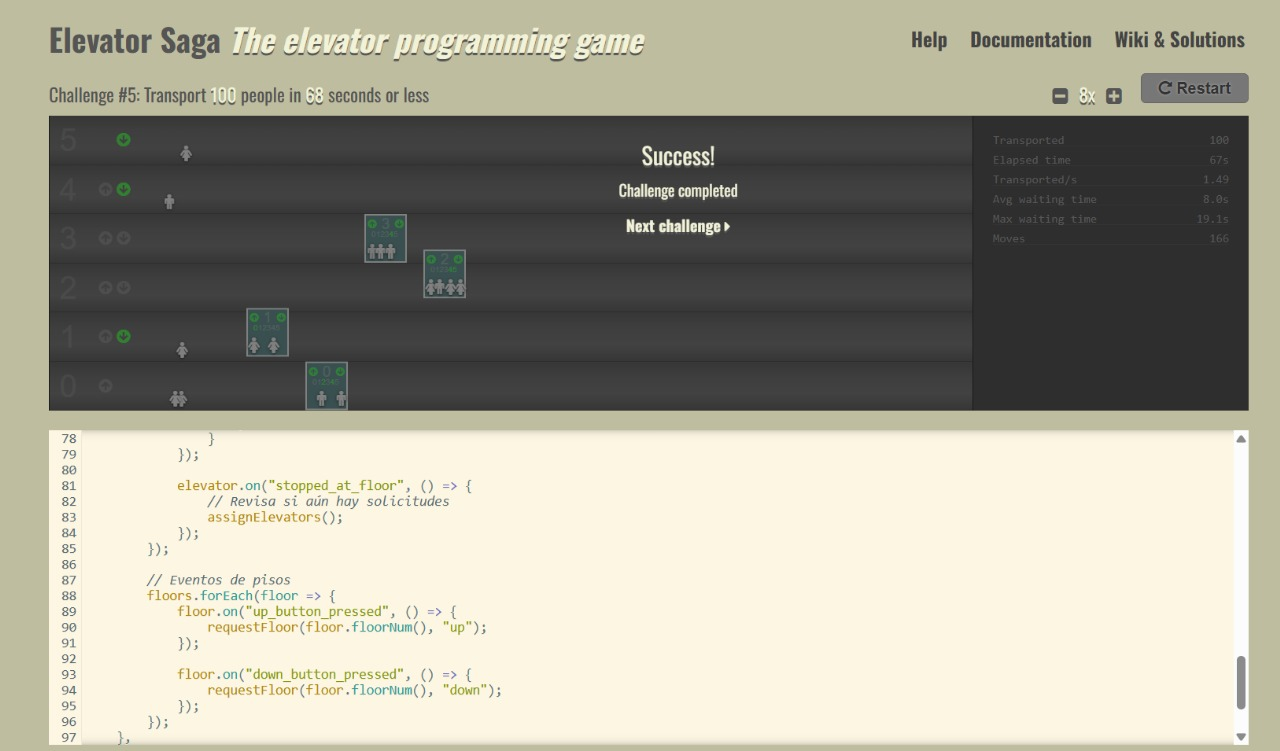

https://drive.google.com/file/d/1RbVpu2QQG8nuwW4W3fisvtMZJ6-HZPtC/view?usp=sharing
VIDEO